# Image Embeddings with fastai
> Exploring how we can extract image embeddings with fastai

- toc: true
- badges: true
- comments: true

In [2]:
#hide
!pip install git+https://github.com/fastai/fastai
!pip install git+https://github.com/fastai/fastcore

  Cloning https://github.com/fastai/fastai to /tmp/pip-req-build-8r8j8e9c
  Running command git clone -q https://github.com/fastai/fastai /tmp/pip-req-build-8r8j8e9c
     |████████████████████████████████| 56 kB 2.0 MB/s 
  Created wheel for fastai: filename=fastai-2.5.4-py3-none-any.whl size=186977 sha256=e1ac0d763496d639fc7fd45b897690a57dd1ce9c852e7e16668695950fd6e4f1
  Stored in directory: /tmp/pip-ephem-wheel-cache-hht98_zv/wheels/40/be/4f/b7f2aec4df5712626ceed9f20a8996eb05e31244e57e58d632
Successfully built fastai
  Attempting uninstall: fastai
    Found existing installation: fastai 1.0.61
    Uninstalling fastai-1.0.61:
      Successfully uninstalled fastai-1.0.61
  Cloning https://github.com/fastai/fastcore to /tmp/pip-req-build-2f6s9ksa
  Running command git clone -q https://github.com/fastai/fastcore /tmp/pip-req-build-2f6s9ksa
  Created wheel for fastcore: filename=fastcore-1.3.27-py3-none-any.whl size=55581 sha256=5960e349f6e076dc6bb5508b56322c9182a11baa305d0d7529e0280d4a9a

We start off by following Chapter 18 of {% cite fastbook2020 %}.

In [3]:
#hide 
from fastai.vision.all import *

In [12]:
path = untar_data(URLs.PETS)/'images'
def is_cat(x): return x[0].isupper()

set_seed(42, reproducible=True)
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2, seed=21,
    label_func=is_cat, item_tfms=Resize(224))

learn = cnn_learner(dls, resnet34, metrics=error_rate)

In [8]:
#collapse-output
learn.model[0]

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [9]:
#collapse-output
learn.model[1]

Sequential(
  (0): AdaptiveConcatPool2d(
    (ap): AdaptiveAvgPool2d(output_size=1)
    (mp): AdaptiveMaxPool2d(output_size=1)
  )
  (1): Flatten(full=False)
  (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Dropout(p=0.25, inplace=False)
  (4): Linear(in_features=1024, out_features=512, bias=False)
  (5): ReLU(inplace=True)
  (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=512, out_features=2, bias=False)
)

In [13]:
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.137692,0.017724,0.006089,01:38


epoch,train_loss,valid_loss,error_rate,time
0,0.061568,0.031254,0.008119,02:14


In [91]:
!cd sample_data/ && wget https://wallup.net/wp-content/uploads/2016/01/18662-cat-Nikon-camera-animals-biting.jpg

--2021-10-25 15:29:44--  https://wallup.net/wp-content/uploads/2016/01/18662-cat-Nikon-camera-animals-biting.jpg
Resolving wallup.net (wallup.net)... 172.67.167.152, 104.21.67.12, 2606:4700:3035::ac43:a798, ...
Connecting to wallup.net (wallup.net)|172.67.167.152|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [image/jpg]
Saving to: ‘18662-cat-Nikon-camera-animals-biting.jpg’

18662-cat-Nikon-cam     [     <=>            ] 661.12K   639KB/s    in 1.0s    

2021-10-25 15:29:46 (639 KB/s) - ‘18662-cat-Nikon-camera-animals-biting.jpg’ saved [676983]



In [92]:
img = PILImage.create('sample_data/18662-cat-Nikon-camera-animals-biting.jpg')
x, = first(dls.test_dl([img]))

In [93]:
x.shape

torch.Size([1, 3, 224, 224])

In [94]:
class Hook():
    def hook_func(self, m, i, o): self.stored = o.detach().clone()

In [95]:
hook_output = Hook()
hook = learn.model[0].register_forward_hook(hook_output.hook_func)

In [96]:
with torch.no_grad(): output = learn.model.eval()(x)

In [97]:
act = hook_output.stored[0]

In [98]:
act.shape, output.shape

(torch.Size([512, 7, 7]), torch.Size([1, 2]))

In [99]:
output

tensor([[-9.2453,  7.4666]], device='cuda:0')

In [100]:
F.softmax(output, dim=-1)

tensor([[5.5223e-08, 1.0000e+00]], device='cuda:0')

Our model is very confident that this is a cat image. Recall that $0$ encodes the class cat while $1$ encodes dog.

In [101]:
cam_map = torch.einsum('ck,kij->cij', learn.model[1][-1].weight, act)
cam_map.shape

torch.Size([2, 7, 7])

In [102]:
cam_map

tensor([[[ 2.4046,  1.6528,  2.2152,  2.8563,  2.5691,  1.1745,  0.1254],
         [ 2.2628,  1.6459,  2.4906,  2.8577,  3.0666,  1.9454,  0.4828],
         [ 2.1937,  1.4049,  0.4718,  1.8430,  2.9179,  3.4975,  2.9062],
         [ 2.6312,  2.3368,  1.5110,  3.3405,  5.6491,  8.0960,  6.5199],
         [ 2.0713,  2.5937,  2.2713,  4.6066,  7.6661,  8.1613,  6.8131],
         [ 3.5682,  5.3845,  4.3552,  4.5040,  5.9994,  6.0594,  4.7016],
         [ 3.8517,  4.8936,  3.5627,  2.7425,  3.3935,  3.0744,  1.8727]],

        [[-1.4491, -0.0725, -0.3290, -0.6133, -0.9042, -0.6929, -0.3612],
         [-1.4582, -0.6994, -0.8243, -1.2838,  0.6312,  1.4840, -0.0306],
         [-3.1769, -3.3927, -1.5584, -0.5836,  2.6498,  4.5836,  2.7395],
         [-1.8686, -1.5165, -0.6451,  0.4035,  3.5035,  5.2182,  3.6719],
         [ 0.2630,  1.0577,  1.3661,  1.4126,  2.6547,  3.0325,  1.4772],
         [-0.1958,  1.0451,  0.3849,  1.1873,  2.8154,  1.1622,  0.9662],
         [ 1.4102,  1.1527,  0.3596,

In [103]:
#collapse-output
dls.train.decode((x,))

(TensorImage([[[[219, 220, 221,  ...,   8,   8,   7],
           [220, 220, 221,  ...,   8,  10,  10],
           [222, 221, 221,  ...,   9,  10,  10],
           ...,
           [ 14,  29,  23,  ...,  60,  54,  60],
           [  4,  20,  36,  ...,  42,  44,  49],
           [  4,   7,  29,  ...,  43,  44,  43]],
 
          [[215, 216, 217,  ...,   7,   6,   6],
           [216, 216, 217,  ...,   6,   7,   7],
           [218, 217, 217,  ...,   6,   7,   7],
           ...,
           [ 11,  24,  14,  ...,  37,  30,  35],
           [  2,  14,  27,  ...,  26,  27,  29],
           [  1,   4,  22,  ...,  28,  29,  27]],
 
          [[214, 215, 215,  ...,   2,   1,   1],
           [214, 213, 214,  ...,   1,   0,   0],
           [215, 214, 214,  ...,   1,   0,   0],
           ...,
           [  4,  12,   7,  ...,  14,  12,  15],
           [  0,   6,  17,  ...,   6,  11,  11],
           [  0,   2,  15,  ...,  10,  10,   8]]]]),)

In [104]:
dls.train.decode((x,))[0].shape, dls.train.decode((x,))[0][0].shape

(torch.Size([1, 3, 224, 224]), torch.Size([3, 224, 224]))

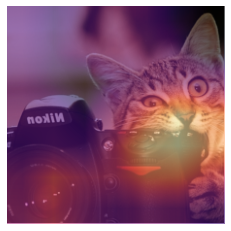

In [124]:
x_dec = TensorImage(dls.train.decode((x,))[0][0])
_,ax = plt.subplots()
x_dec.show(ctx=ax)
ax.imshow(cam_map[0].detach().cpu(), alpha=0.6, extent=(0,224,224,0),
              interpolation='bilinear', cmap='magma');

The network appears to be focussing on the mouth.

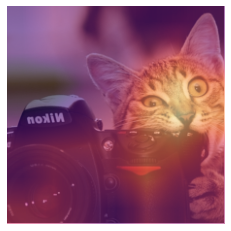

In [106]:
x_dec = TensorImage(dls.train.decode((x,))[0][0])
_,ax = plt.subplots()
x_dec.show(ctx=ax)
ax.imshow(cam_map[1].detach().cpu(), alpha=0.6, extent=(0,224,224,0),
              interpolation='bilinear', cmap='magma');

The network appears to be focussing on the entire face.

Compare this to a random activations map where, in comparison, there is no singular area of focus.

In [111]:
rand_cmap = torch.randn((7,7), device='cuda:0')
rand_cmap

tensor([[-0.6246, -2.0889, -0.2410,  0.1757,  0.4851, -0.0344, -1.1643],
        [ 0.8202,  0.0317, -1.2319, -0.3309, -0.8361,  0.0372,  0.7829],
        [-2.1245,  0.3767,  0.2770, -1.7410, -0.4939,  0.3442,  1.2135],
        [ 0.3845, -0.0761, -1.0676,  0.4595, -1.0003,  1.3858, -0.5216],
        [-0.7303,  0.2951,  0.8872,  1.0252,  3.0105, -0.4085, -1.0285],
        [-1.2513, -0.4096, -0.1647, -0.2257,  0.3022,  1.9342, -0.9235],
        [ 1.9612,  1.0709,  0.2771, -0.9505, -2.1714,  0.8185,  0.8648]],
       device='cuda:0')

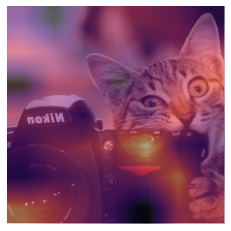

In [112]:
x_dec = TensorImage(dls.train.decode((x,))[0][0])
_,ax = plt.subplots()
x_dec.show(ctx=ax)
ax.imshow(rand_cmap.detach().cpu(), alpha=0.6, extent=(0,224,224,0),
              interpolation='bilinear', cmap='magma');

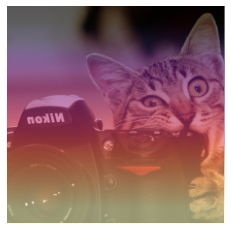

In [117]:
x_dec = TensorImage(dls.train.decode((x,))[0][0])
_,ax = plt.subplots()
x_dec.show(ctx=ax)
ax.imshow(my_map, alpha=0.6, extent=(0,224,224,0),
              interpolation='bilinear', cmap='magma');

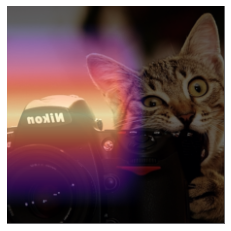

In [127]:
my_map = tensor([[0., 0., 0.,  0.,  0., 0., 0.],
        [ 1.,  1., 1., 1., 0.,  0.,  0.],
        [ 2.,  2., 2., 2., 0.,  0.,  0.],
        [ 3.,  3., 3., 3., 0.,  0.,  0.],
        [ 2.,  2., 2., 2., 0.,  0.,  0.],
        [ 1.,  1., 1., 1., 0.,  0.,  0.],
        [ 0.,  0., 0., 0., 0.,  0.,  0.]])

x_dec = TensorImage(dls.train.decode((x,))[0][0])
_,ax = plt.subplots()
x_dec.show(ctx=ax)
ax.imshow(my_map, alpha=0.6, extent=(0,224,224,0),
              interpolation='bilinear', cmap='magma');

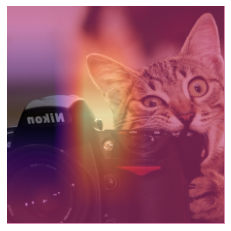

In [132]:
my_map = tensor([[0., 0., 0.,  0.,  0., 0., 0.],
        [ -1.,  -1., 1., 1., 0.,  0.,  0.],
        [ -2.,  -2., 2., 2., 0.,  0.,  0.],
        [ -3.,  -3., 3., 3., 0.,  0.,  0.],
        [ -2.,  -2., 2., 2., 0.,  0.,  0.],
        [ -1.,  -1., 1., 1., 0.,  0.,  0.],
        [ 0.,  0., 0., 0., 0.,  0.,  0.]])

x_dec = TensorImage(dls.train.decode((x,))[0][0])
_,ax = plt.subplots()
x_dec.show(ctx=ax)
ax.imshow(my_map, alpha=0.6, extent=(0,224,224,0),
              interpolation='bilinear', cmap='magma');

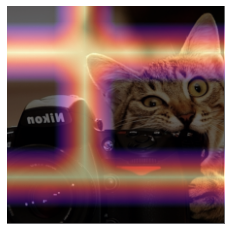

In [123]:
my_map = tensor([[0., 0., 1.,  0.,  0., 0., 0.],
        [ 1.,  1., 1., 1., 1.,  1.,  1.],
        [ 0., 0., 1.,  0.,  0., 0., 0.],
        [ 0., 0., 1.,  0.,  0., 0., 0.],
        [ 0., 0., 1.,  0.,  0., 0., 0.],
        [ 1.,  1., 1., 1., 1.,  1.,  1.],
        [ 0.,  0., 0., 0., 0.,  0.,  0.]])

x_dec = TensorImage(dls.train.decode((x,))[0][0])
_,ax = plt.subplots()
x_dec.show(ctx=ax)
ax.imshow(my_map, alpha=0.6, extent=(0,224,224,0),
              interpolation='bilinear', cmap='magma');

In [ ]:
hook.remove()

# References
{% bibliography --cited %}